# 1. Data Loading and Preparation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = sns.load_dataset("taxis")
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


### Handling Missing Values:

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Impute missing numerical values with median
df['distance'] = df['distance'].fillna(df['distance'].median())

# Remove rows for critical columns that cannot be reasonably imputed
df.dropna(subset=['pickup', 'dropoff'], inplace=True)

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


# Visualizations using Matplotlib/Pandas Plot

<Axes: xlabel='pickup'>

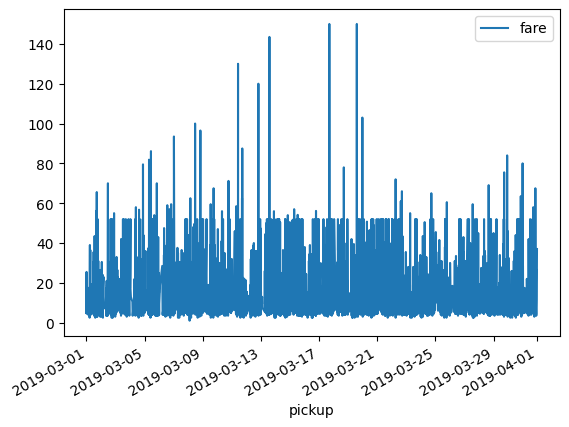

In [ ]:
# Line chart
df['pickup'] = pd.to_datetime(df['pickup'])
df.sort_values('pickup').plot(x='pickup', y='fare', kind='line')

<Axes: xlabel='pickup_borough'>

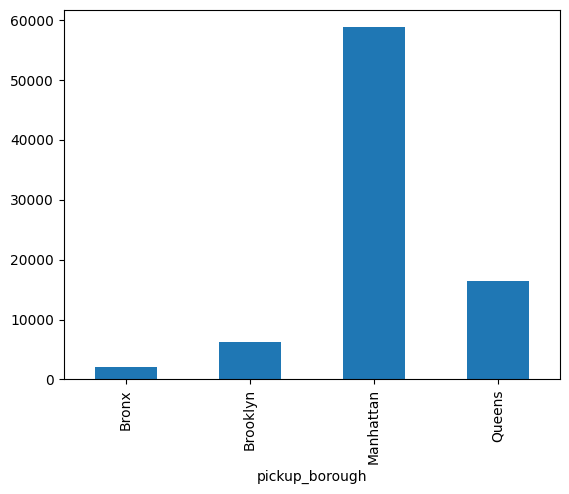

In [ ]:
# Bar chart
df.groupby('pickup_borough')['fare'].sum().plot(kind='bar')

<Axes: ylabel='count'>

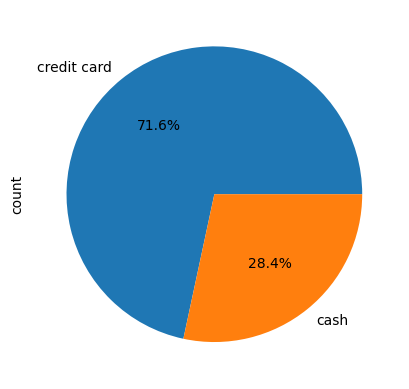

In [ ]:
# Pie Chart
df['payment'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: ylabel='Frequency'>

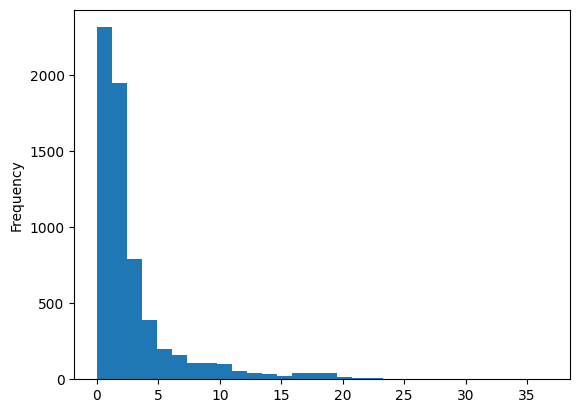

In [ ]:
# Histogram
df['distance'].plot(kind='hist', bins=30)

<Axes: title={'center': 'tip'}, xlabel='pickup_borough'>

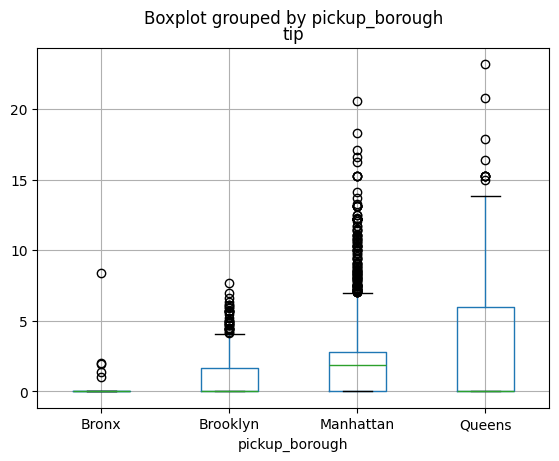

In [ ]:
# Box plot
df.boxplot(column='tip', by='pickup_borough')

# 3. Visualizations using Seaborn

<Axes: xlabel='pickup_borough', ylabel='count'>

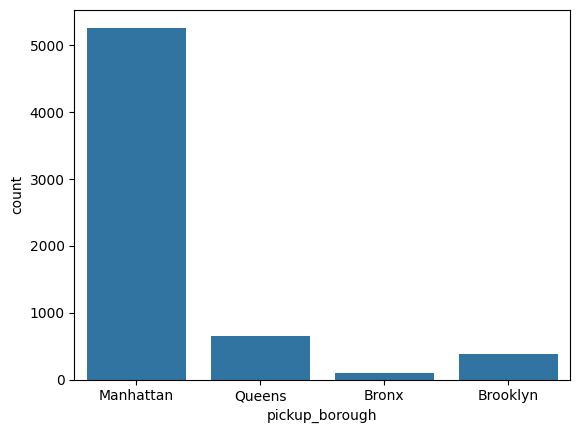

In [ ]:
 # Count Plot: Number of trips per pickup borough.
sns.countplot(data=df, x='pickup_borough')

<Axes: xlabel='distance', ylabel='fare'>

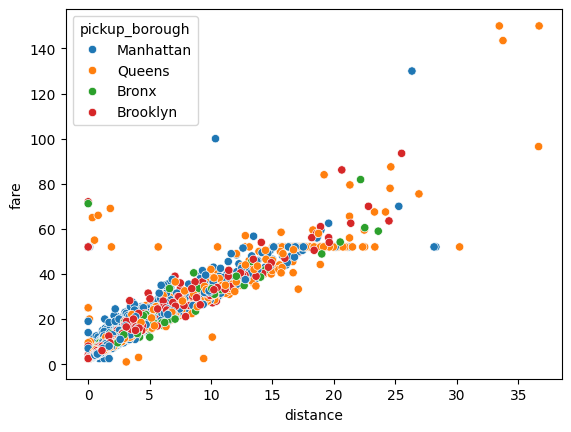

In [ ]:
# Scatter Plot: Relationship between distance and fare
sns.scatterplot(data=df, x='distance', y='fare', hue='pickup_borough')

<Axes: >

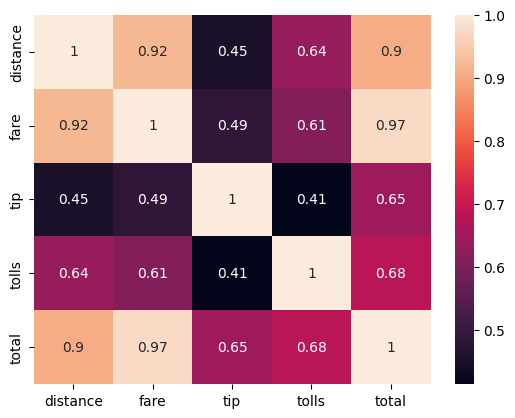

In [ ]:
# Heatmap: Correlation between numerical variables.
corr_matrix = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()
sns.heatmap(corr_matrix, annot=True)

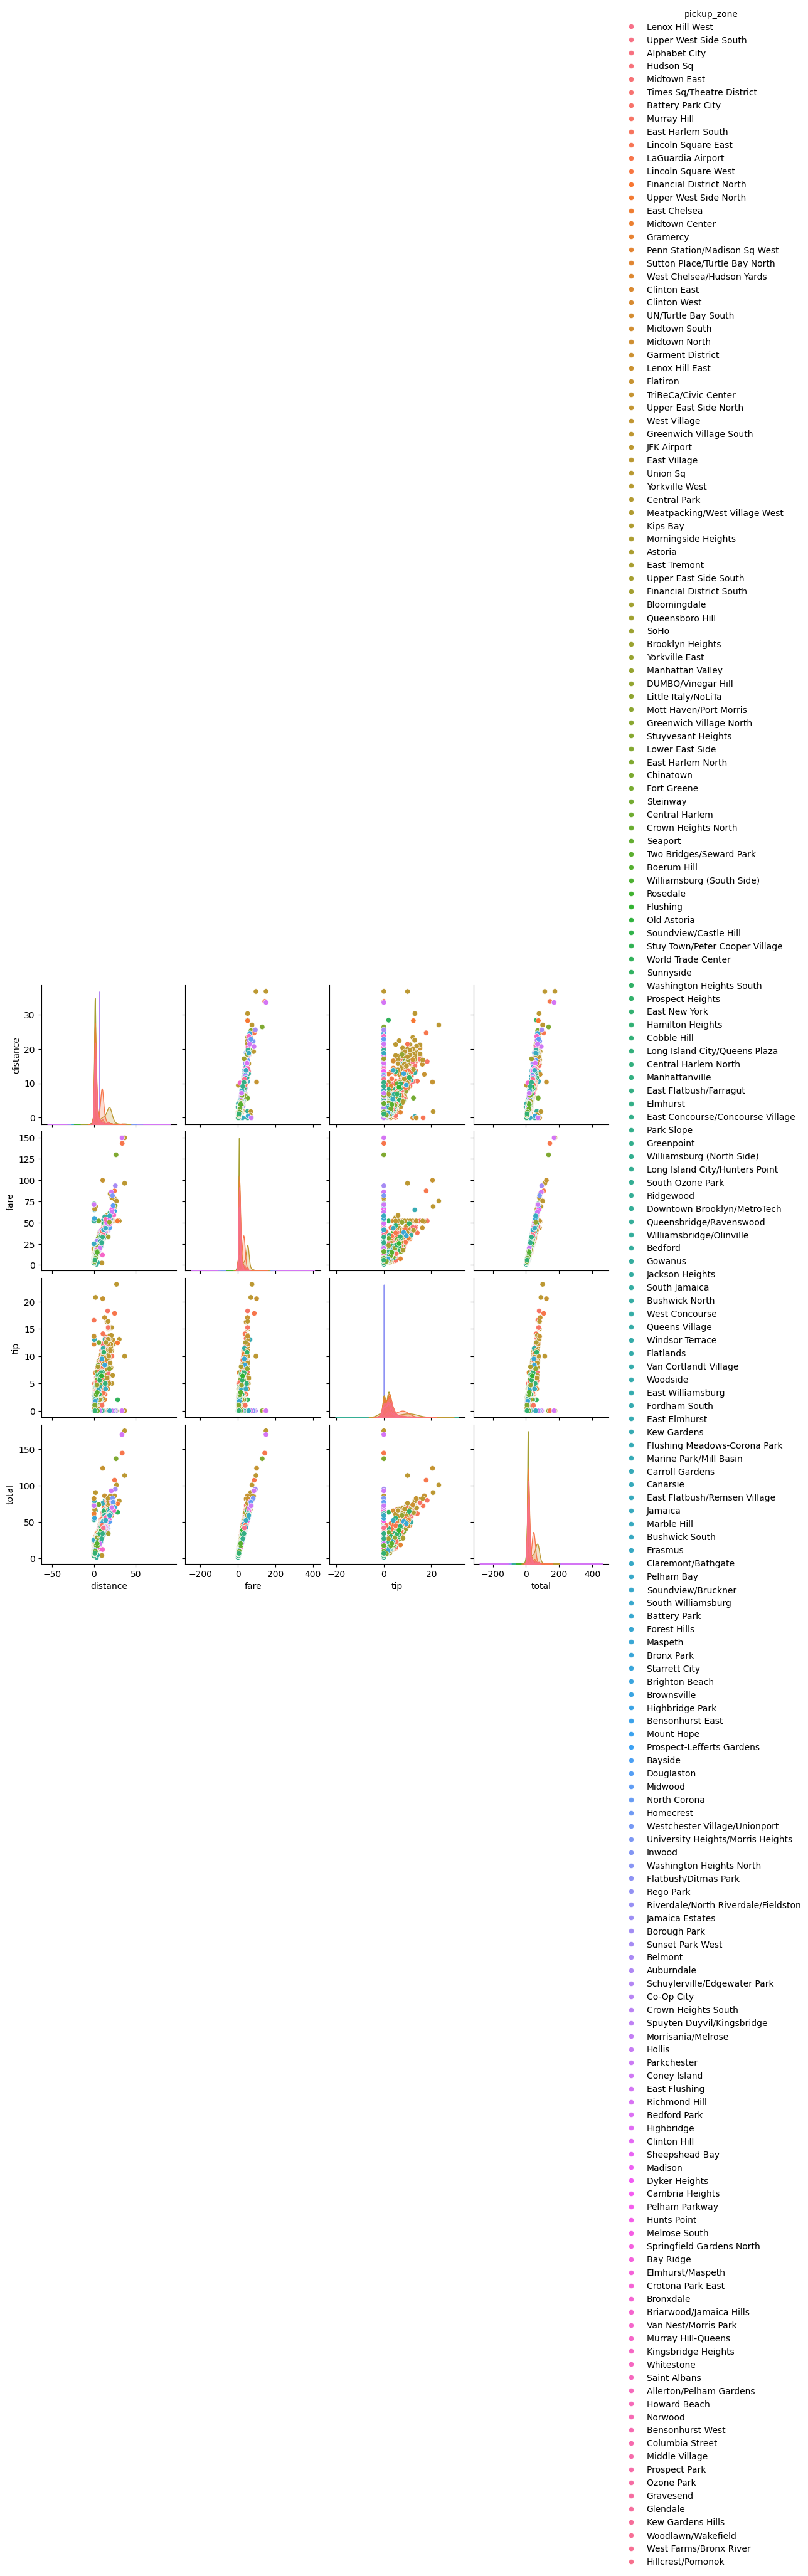

In [ ]:
# Pair Plot: Pairwise relationships colored by pickup zone.
sns.pairplot(df[['distance', 'fare', 'tip', 'total', 'pickup_zone']], hue='pickup_zone')

<Axes: xlabel='payment', ylabel='fare'>

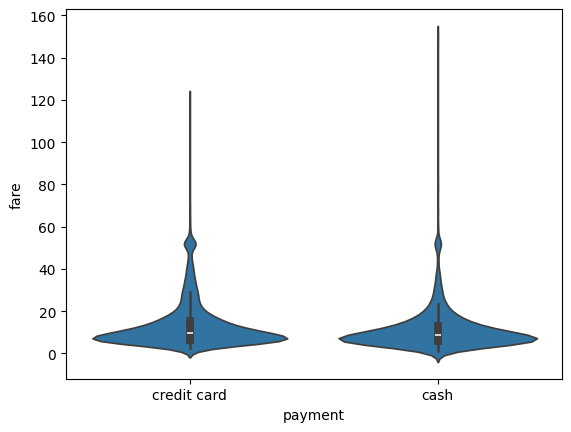

In [ ]:
# Violin Plot: Fare distribution across different payment methods
sns.violinplot(data=df, x='payment', y='fare')